Downloading dataset from kaggel - https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset

In [1]:
! \
curl -L -o rice-image-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/muratkokludataset/rice-image-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  219M  100  219M    0     0   124M      0  0:00:01  0:00:01 --:--:--  183M


In [2]:
!unzip rice-image-dataset.zip -d rice-image-dataset

Streaming output truncated to the last 5000 lines.
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (55).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (550).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5500).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5501).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5502).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5503).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5504).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5505).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5506).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5507).jpg  
  inflating: rice-image-dataset/Rice_Image_Dataset/Karacadag/Karacadag (5508).jpg  
  inflating: rice-image-data

creating custom dataclass for our data

In [22]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

class RiceGrainDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self.idx_to_class = {}

        # 1. Scan the directory to find class names (folder names)
        # We sort them to ensure specific indices (0, 1, 2...) are consistent every run
        classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

        # 2. Create the Name-to-ID mapping
        for idx, class_name in enumerate(classes):
            self.class_to_idx[class_name] = idx
            self.idx_to_class[idx] = class_name

            # 3. Collect all image paths for this class
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    file_path = os.path.join(class_dir, filename)
                    self.samples.append((file_path, idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label_id = self.samples[idx]

        # Open image and convert to RGB (crucial for consistency)
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            return self.__getitem__(idx + 1) # Skip to next if corrupt

        if self.transform:
            image = self.transform(image)

        return image, label_id

In [23]:
# for mobilenet
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]
#for effiecient net lite values
#
# norm_mean=[0.5, 0.5, 0.5]
# norm_std=[0.5, 0.5, 0.5]
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),      # Resize to standard input
    transforms.RandomHorizontalFlip(),  # Augmentation: Flip left/right
    transforms.RandomRotation(15),      # Augmentation: Slight rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Handle lighting variations
    transforms.ToTensor(),              # Convert [0, 255] to Tensor [0.0, 1.0]
    transforms.Normalize(norm_mean, norm_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(norm_mean, norm_std)
])

In [24]:

full_dataset = RiceGrainDataset(root_dir='./rice-image-dataset/Rice_Image_Dataset', transform=train_transforms)
# #using batch_size = 64 we can adjust this on training memory resource
BATCH_SIZE = 64

print(f"Total Images Found: {len(full_dataset)}")
print(f"Class Mapping: {full_dataset.class_to_idx}")

#doing 80 20 split for train test data
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

#using diferent transform for test data
val_subset.dataset.transform = val_transforms

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,  num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,  drop_last=True, num_workers=2)

train_loader_batch_size_1 = DataLoader(train_subset, batch_size=1, shuffle=True, num_workers=2)
val_loader_batch_size_1 = DataLoader(val_subset, batch_size=1, shuffle=True, num_workers=2)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Total Images Found: 75000
Class Mapping: {'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}
Training batches: 937
Validation batches: 234


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to un-normalize and show image
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0)) # Convert CxHxW to HxWxC
    mean = np.array(norm_mean)
    std = np.array(norm_std)
    img = std * img + mean # Un-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.show()



Label ID: 3
Label Name: Jasmine


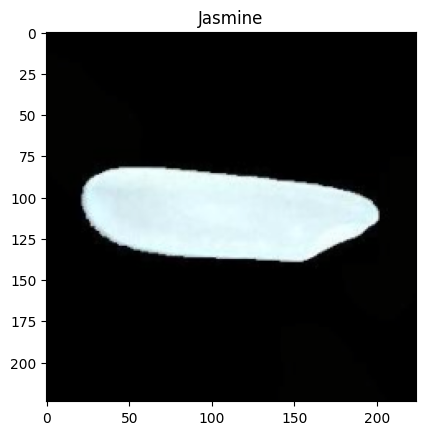

In [ ]:
# Get one batch of data
data_iterator = iter(train_loader)
images, labels = next(data_iterator)

# Show the first image in the batch
print(f"Label ID: {labels[0].item()}")
print(f"Label Name: {full_dataset.idx_to_class[labels[0].item()]}")

imshow(images[0], title=full_dataset.idx_to_class[labels[0].item()])

In [26]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import time
import copy
import gc
import timm
from tqdm import tqdm


In [27]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#
#

In [31]:

# def get_modified_model(num_classes=5):
#     # Loading Pre-trained MobileNetV3 Small
#     model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

#     #changing last layer from conv feature block to linear layer for our classification task
#     in_features = model.classifier[3].in_features

#     model.classifier[3] = nn.Linear(in_features, num_classes)

#     return model
def get_modified_model(num_classes=5):
    # Loading Pre-trained MobileNetV3 Small
    model = models.mobilenetv2.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

    #changing last layer from conv feature block to linear layer for our classification task
    in_features = model.classifier[1].in_features

    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model

# # Initialize
model = get_modified_model().to(device)

In [32]:
#Hyperparams
LR = 0.001
NUM_EPOCH = 3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [34]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    since = time.time()

    # Store results to plot later
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)

        # --- TRAINING PHASE ---
        model.train()  # Set model to training mode (enables Dropout, BatchNorm updates)
        running_loss = 0.0
        running_corrects = 0

        for i ,(inputs, labels ) in enumerate(tqdm(train_loader)):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Backward pass + Optimize
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0) # Multiply by batch size to get total loss
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # --- VALIDATION PHASE ---
        model.eval()   # Set model to evaluate mode (disables Dropout)
        val_running_loss = 0.0
        val_running_corrects = 0

        # We do not compute gradients during validation to save memory and speed up
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(tqdm(val_loader)):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_running_corrects.double() / len(val_loader.dataset)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())

        print(f'Val   Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # Deep copy the model if it's the best one so far
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            # Save strictly the best model
            torch.save(model.state_dict(), f"rice_model_epoch_mobilenetv2:{epoch+1}_loss:{val_loss:.2f}.pth")
            print("  -> Best model saved!")

        print("\n") # Empty line for readability

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history



In [35]:
#Training
gc.collect()

# Release all unoccupied cached memory held by the CUDA caching allocator
if torch.cuda.is_available():
    torch.cuda.empty_cache()

#stopped training early as we were getting 99% accuracy
trained_model, training_history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCH)

Epoch 1/3
----------


100%|██████████| 937/937 [04:01<00:00,  3.89it/s]


Train Loss: 0.0323 Acc: 0.9895


100%|██████████| 234/234 [00:38<00:00,  6.14it/s]


Val   Loss: 0.2855 Acc: 0.9214
  -> Best model saved!


Epoch 2/3
----------


...

Train Loss: 0.0137 Acc: 0.9956


100%|██████████| 234/234 [00:39<00:00,  5.95it/s]


Val   Loss: 0.0104 Acc: 0.9950
  -> Best model saved!


Epoch 3/3
----------


 32%|███▏      | 300/937 [01:17<02:43,  3.89it/s]


KeyboardInterrupt: 

In [ ]:
def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.show()

# Run the plotter
plot_training_history(training_history)

NameError: name 'training_history' is not defined

In [9]:
!pip install executorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.1/538.1 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7

In [ ]:
!pip install torchao

In [36]:
import torch
import torch.nn as nn
from torch.export import export
from executorch.exir import to_edge
from executorch.exir import EdgeCompileConfig
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner
# Quantization Imports (PT2E flow)
from torch.ao.quantization.quantize_pt2e import prepare_pt2e, convert_pt2e
from torch.ao.quantization.quantizer.xnnpack_quantizer import (
    XNNPACKQuantizer,
    get_symmetric_quantization_config, QuantizationConfig, QuantizationSpec
)
from tqdm import tqdm
from torch.ao.quantization.observer import HistogramObserver, MovingAverageMinMaxObserver, PerChannelMinMaxObserver, MinMaxObserver

Quantizing float32 model to int8 and exporting to executorch format **Post TRAINING QUANTIZATION**

In [37]:
import warnings
warnings.filterwarnings('ignore')
# comment this to see logs and warnings

In [46]:
import executorch.extension.pybindings.portable_lib
import executorch.kernels.quantized
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

# Initialize and load weights
model = get_modified_model(num_classes=5)
model.load_state_dict(torch.load("rice_model_epoch_mobilenetv2:2_loss:0.01.pth", map_location="cpu"))
model.eval()

# Create a dummy input for the export tracer
example_input = (torch.randn(1, 3, 224, 224),)

#Capturing the graph using torch.export
print("Exporting model graph...")
exported_model = export(model, example_input)

quantizer = XNNPACKQuantizer()

######################### #THIS CONFIG GOT 98% accuracy 2.5MB model ################

# global_config = get_symmetric_quantization_config(is_per_channel=True)
# quantizer.set_global(global_config)

# linear_config = get_symmetric_quantization_config(is_per_channel=True)
# quantizer.set_module_type(nn.Linear, linear_config)


################################## #This config got 39% accuracy model size 2.21MB #################

# config = get_symmetric_quantization_config(is_per_channel=False, is_qat=False)
# quantizer.set_global(config)

####################################### #THIS CONFIG GOT 98% accuracy 8.47 MB model################
#instead of doing global quantization we will do per channel for conv layers \
#to preserve sensitive values and using common quantization for linear layer that are redundant
global_config = get_symmetric_quantization_config(
    is_per_channel=False,
    is_qat=False
)

try:
    # Trying per-channel for conv layers
    conv_config = get_symmetric_quantization_config(
        is_per_channel=True,
        is_qat=False
    )
    quantizer.set_module_type(torch.nn.Conv2d, conv_config)

except:
    print("Per-channel not supported, using per-tensor for all layers")
# Set global config for all other layers
quantizer.set_global(global_config)
#######################################################################



print("Preparing model for quantization...")
prepared_model = prepare_pt2e(exported_model.module(), quantizer)

# calibrating on train data
print("Calibrating ...")

try:
#
    print("found train loader batch 1")
    data_iter = iter(train_loader_batch_size_1)
    # trying with different steps to see its effect
    for i in tqdm(range(1000)):
        images, _ = next(data_iter)
        # The prepared_model (now a GraphModule) expects a single tensor input
        prepared_model(images)
except Exception as e:
    print(f"Warning: 'train_loader' not found. Using random noise for calibration (NOT RECOMMENDED for accuracy). {e}")

print("Converting to Int8...")
# conveting to int8
quantized_model_module = convert_pt2e(prepared_model)

print("Re-exporting quantized graph...")

quantized_exported_program = torch.export.export(quantized_model_module, example_input)

print("Lowering to ExecuTorch Edge IR...")

edge_program_manager = to_edge_transform_and_lower(
    quantized_exported_program,
    partitioner=[XnnpackPartitioner()]
)

executorch_program = edge_program_manager.to_executorch()
# Save the file
output_file = "rice_model_mobilenetv2_quantized.pte"
with open(output_file, "wb") as f:
    f.write(executorch_program.buffer)

print(f"SUCCESS! Model saved to {output_file}")
file_size = os.path.getsize(output_file) / (1024 * 1024)

print(f"✅ File size: {file_size:.2f} MB")

Exporting model graph...
Preparing model for quantization...
Calibrating ...
found train loader batch 1


100%|██████████| 1000/1000 [00:56<00:00, 17.77it/s]


Converting to Int8...
Re-exporting quantized graph...
Lowering to ExecuTorch Edge IR...
SUCCESS! Model saved to rice_model_mobilenetv2_quantized.pte
✅ File size: 8.47 MB


In [ ]:
import torch
from executorch.runtime import Runtime, Program, Method

print("Initializing ExecuTorch Runtime...")
runtime_instance = Runtime.get()

pte_path = "rice_model_quantized.pte"
try:
    program = runtime_instance.load_program(pte_path)
    print(f"Successfully loaded '{pte_path}'")
except Exception as e:
    print(f"Error loading model: {e}")


method_name = "forward"
try:
    method = program.load_method(method_name)
    print(f"Method '{method_name}' loaded ready for inference.")
except Exception as e:
    print(f"Error loading method '{method_name}': {e}")


input_tensor = torch.randn(1, 3, 224, 224)

try:
    outputs = method.execute([input_tensor])
    print("✅ Inference completed successfully!")
except Exception as e:
    print(f"❌ Inference failed: {e}")


[program.cpp:153] InternalConsistency verification requested but not available


Initializing ExecuTorch Runtime...
Successfully loaded 'rice_model_quantized.pte'
Method 'forward' loaded ready for inference.
✅ Inference completed successfully!


In [ ]:
!pip install scikit-learn seaborn tqdm

In [39]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from executorch.runtime import Runtime


In [40]:
# 4. Plot Confusion Matrix
# ---------------------------------------------------------
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Green for Baseline
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (Original Float32 Model)')
    plt.show()

Evaluating baseline model

Evaluating on: cuda
Starting Inference on Validation Set (Float32 Model)...


Evaluating: 100%|██████████| 235/235 [00:40<00:00,  5.85it/s]



--- Baseline (Float32) Evaluation Results ---
Overall Accuracy: 99.82%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9966    0.9966    0.9966      2928
     Basmati     0.9997    0.9980    0.9989      3054
      Ipsala     1.0000    1.0000    1.0000      2998
     Jasmine     0.9946    0.9993    0.9970      2968
   Karacadag     1.0000    0.9971    0.9985      3052

    accuracy                         0.9982     15000
   macro avg     0.9982    0.9982    0.9982     15000
weighted avg     0.9982    0.9982    0.9982     15000



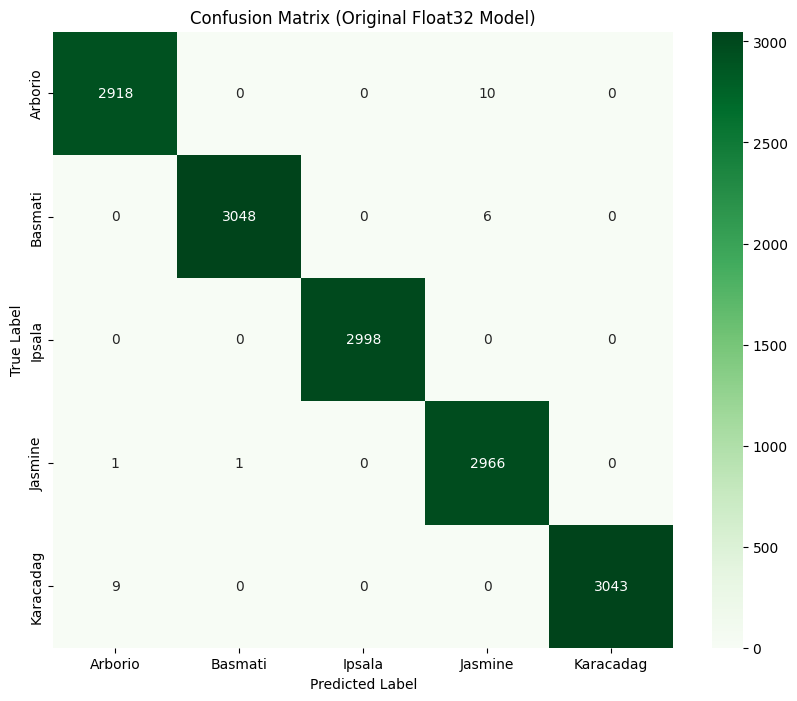

In [ ]:


# 1. Setup Device and Load Model
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on: {device}")

# Re-initialize the architecture
# Ensure this matches the architecture used in training
model = get_modified_model(num_classes=len(full_dataset.class_to_idx))

# Load the trained Float32 weights
model.load_state_dict(torch.load("rice_model_epoch_mobilenetv2:2_loss:0.01.pth", map_location=device))

# Move to device and set to Evaluation mode (Critical!)
model.to(device)
model.eval()

# 2. Inference Loop
# ---------------------------------------------------------
y_true = []
y_pred = []

print("Starting Inference on Validation Set (Float32 Model)...")

# We use 'val_loader' (Batch Size 32) for faster processing
with torch.no_grad(): # Disable gradient calculation to save memory
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward Pass
        outputs = model(inputs)

        # Get Predictions
        # dim=1 is the class dimension
        _, preds = torch.max(outputs, 1)

        # Append to lists (Move to CPU first)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 3. Calculate Metrics
# ---------------------------------------------------------
print("\n--- Baseline (Float32) Evaluation Results ---")

# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

Evaluating post training quantize model

[program.cpp:153] InternalConsistency verification requested but not available


Total Test Images: 15000
Loading rice_model_mobilenetv2_quantized_98%.pte...
Model loaded successfully!
Starting Inference on Validation Set...


Evaluating: 100%|██████████| 15000/15000 [04:26<00:00, 56.30it/s]



--- Evaluation Results ---
rice_model_mobilenetv2_quantized_98%.pte
Overall Accuracy: 98.69%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9997    0.9636    0.9813      3052
     Basmati     0.9730    1.0000    0.9863      2956
      Ipsala     0.9821    1.0000    0.9910      2971
     Jasmine     0.9912    0.9726    0.9818      3024
   Karacadag     0.9891    0.9993    0.9942      2997

    accuracy                         0.9869     15000
   macro avg     0.9870    0.9871    0.9869     15000
weighted avg     0.9871    0.9869    0.9869     15000



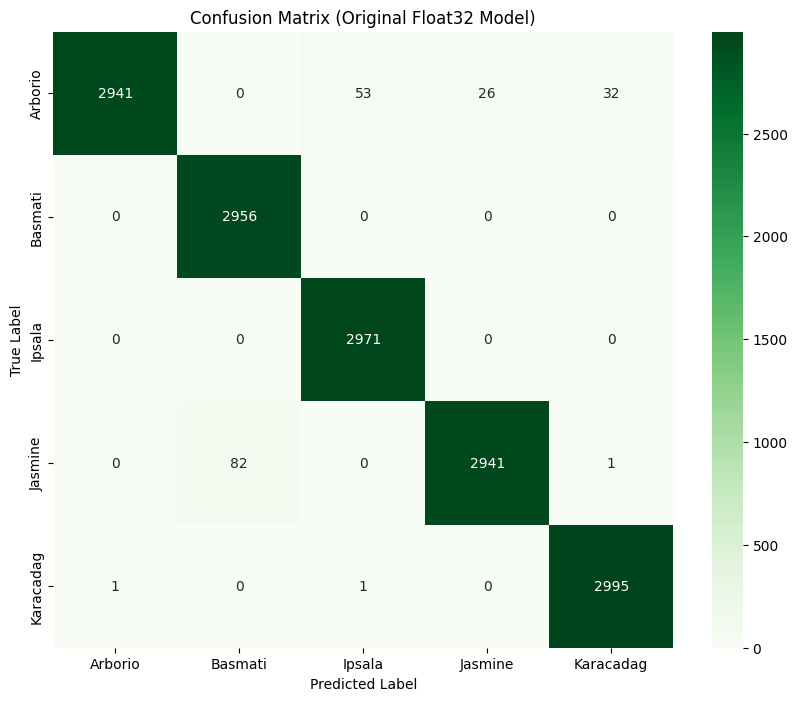

In [43]:
"""
Model with 98% accuracy but slight bigger model size 2.36MB config - global_config = get_symmetric_quantization_config(is_per_channel=True)

quantizer.set_global(global_config)

linear_config = get_symmetric_quantization_config(is_per_channel=True)
quantizer.set_module_type(nn.Linear, linear_config)

"""
from executorch.runtime import Runtime, Program, Method

eval_loader = DataLoader(val_subset, batch_size=1, shuffle=True, drop_last=True)

print(f"Total Test Images: {len(eval_loader)}")

# 2. Load the ExecuTorch Model
# ---------------------------------------------------------
pte_path = "rice_model_mobilenetv2_quantized_98%.pte"
print(f"Loading {pte_path}...")

try:
    runtime_instance = Runtime.get()
    program = runtime_instance.load_program(pte_path)
    method_name = "forward"
    method = program.load_method(method_name)
    print("Model loaded successfully!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not load model. {e}")


# 3. Inference Loop
# ---------------------------------------------------------
y_true = []
y_pred = []
inference_times = []

print("Starting Inference on Validation Set...")

# We iterate through the loader
# tqdm adds a progress bar so you know how long it will take
for inputs, labels in tqdm(eval_loader, desc="Evaluating"):
    # ExecuTorch runs on CPU, so ensure inputs are standard CPU tensors
    # inputs shape is [1, 3, 224, 224]


    # Execute Model
    # method.execute() expects a list of inputs
    outputs = method.execute([inputs])

    # Get the output tensor (Logits)
    logits = outputs[0] # output[0] corresponds to the first return value

    # Get Prediction (Argmax)
    # We use torch.argmax to find the index of the highest score
    predicted_id = torch.argmax(logits, dim=1).item()

    # Store results
    y_pred.append(predicted_id)
    y_true.append(labels.item())

# 4. Calculate Metrics
# ---------------------------------------------------------
print("\n--- Evaluation Results ---")
print(f"{pte_path}")
# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

[program.cpp:153] InternalConsistency verification requested but not available


Total Test Images: 15000
Loading rice_model_mobilenetv2_quantized.pte...
Model loaded successfully!
Starting Inference on Validation Set...


Evaluating: 100%|██████████| 15000/15000 [04:26<00:00, 56.37it/s]



--- Evaluation Results ---
rice_model_mobilenetv2_quantized.pte
Overall Accuracy: 39.97%

Detailed Classification Report:
              precision    recall  f1-score   support

     Arborio     0.2816    0.9984    0.4393      3052
     Basmati     0.7048    0.9932    0.8245      2956
      Ipsala     0.0000    0.0000    0.0000      2971
     Jasmine     1.0000    0.0043    0.0086      3024
   Karacadag     0.0000    0.0000    0.0000      2997

    accuracy                         0.3997     15000
   macro avg     0.3973    0.3992    0.2545     15000
weighted avg     0.3978    0.3997    0.2536     15000



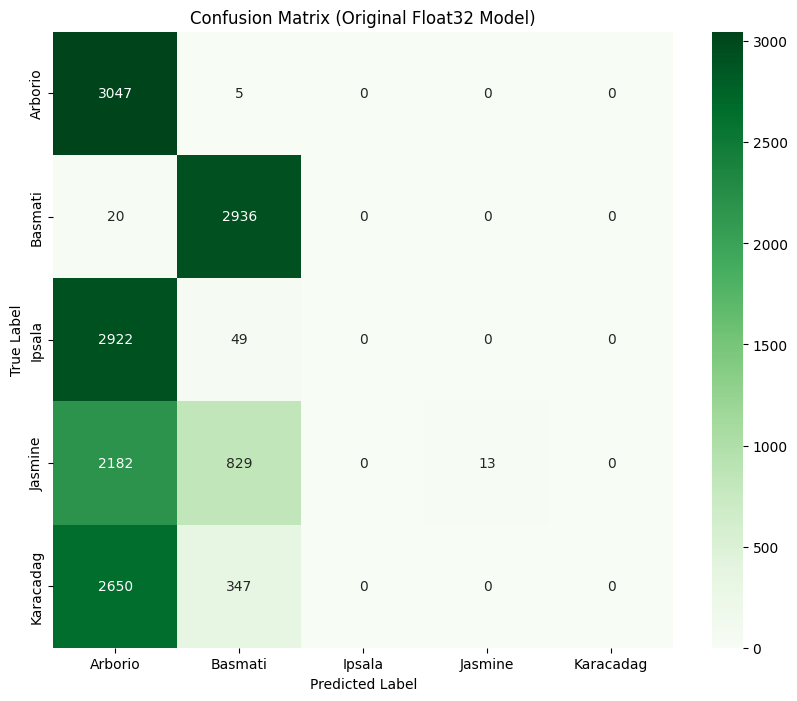

In [45]:
""" Model with 66% - config = get_symmetric_quantization_config(is_per_channel=False, is_qat=False)
quantizer.set_global(config)"""
###
from executorch.runtime import Runtime, Program, Method

eval_loader = DataLoader(val_subset, batch_size=1, shuffle=True, drop_last=True)

print(f"Total Test Images: {len(eval_loader)}")

# 2. Load the ExecuTorch Model
# ---------------------------------------------------------
pte_path = "rice_model_mobilenetv2_quantized_39%.pte.pte"
print(f"Loading {pte_path}...")

try:
    runtime_instance = Runtime.get()
    program = runtime_instance.load_program(pte_path)
    method_name = "forward"
    method = program.load_method(method_name)
    print("Model loaded successfully!")
except Exception as e:
    print(f"CRITICAL ERROR: Could not load model. {e}")


# 3. Inference Loop
# ---------------------------------------------------------
y_true = []
y_pred = []
inference_times = []

print("Starting Inference on Validation Set...")

# We iterate through the loader
# tqdm adds a progress bar so you know how long it will take
for inputs, labels in tqdm(eval_loader, desc="Evaluating"):
    # ExecuTorch runs on CPU, so ensure inputs are standard CPU tensors
    # inputs shape is [1, 3, 224, 224]


    # Execute Model
    # method.execute() expects a list of inputs
    outputs = method.execute([inputs])

    # Get the output tensor (Logits)
    logits = outputs[0] # output[0] corresponds to the first return value

    # Get Prediction (Argmax)
    # We use torch.argmax to find the index of the highest score
    predicted_id = torch.argmax(logits, dim=1).item()

    # Store results
    y_pred.append(predicted_id)
    y_true.append(labels.item())

# 4. Calculate Metrics
# ---------------------------------------------------------
print("\n--- Evaluation Results ---")
print(f"{pte_path}")
# A. Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

# B. Detailed Report (Precision, Recall, F1-Score)
class_names = [full_dataset.idx_to_class[i] for i in range(len(full_dataset.class_to_idx))]

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nDetailed Classification Report:")
print(report)



plot_confusion_matrix(y_true, y_pred, class_names)

In [ ]:
!ls -lh .

total 230M
drwxr-xr-x 3 root root 4.0K Dec 15 16:13 rice-image-dataset
-rw-r--r-- 1 root root 220M Dec 15 16:13 rice-image-dataset.zip
-rw-r--r-- 1 root root 6.0M Dec 15 16:18 rice_model__epoch_0_loss_0.01.pth
-rw-r--r-- 1 root root 4.2M Dec 15 16:39 rice_model_ptq_optimized.pte
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data
